# **Member 4 – Performance Analytics**
## evaluation_charts.ipynb
Pulls benchmark metrics from `performance_results.csv` and generates publication-quality comparison charts covering **execution time**, **throughput**, and a **composite summary**.

## **Part 1 – Setup & Mount Drive**

In [24]:
# Install / upgrade visualisation libraries
!pip install -q seaborn plotly kaleido

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings, os
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/DataDucks Project P1'
OUT  = BASE  # save charts alongside the project files
print('Drive mounted. Output path:', OUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Output path: /content/drive/MyDrive/DataDucks Project P1


## **Part 2 – Load Performance Data**

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

# ── Upload performance_metrics.csv directly if it's not in Drive ──
from google.colab import files
import io

print("Please upload your performance_metrics.csv file:")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# Rename all 5 columns for convenience, matching the new CSV structure
df.columns = [
    'Method',
    'Exec_Time_s',
    'CPU_Usage_pct',
    'Memory_Usage_pct',
    'Throughput_rps'
]

# Derived metrics
df['Throughput_krps'] = df['Throughput_rps'] / 1000
df['Speedup_vs_Seq']  = df.loc[df.Method=='Sequential', 'Exec_Time_s'].values[0] / df['Exec_Time_s']

PALETTE = {
    'Sequential':     '#4C72B0',
    'Multithreading': '#DD8452',
    'Multiprocessing':'#55A868',
    'Dask':           '#C44E52',
}
COLORS = [PALETTE[m] for m in df['Method']]

print(df.to_string(index=False))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Please upload your performance_metrics.csv file:


Saving performance_metrics.csv to performance_metrics (1).csv
         Method  Exec_Time_s  CPU_Usage_pct  Memory_Usage_pct  Throughput_rps  Throughput_krps  Speedup_vs_Seq
     Sequential     0.644428           57.7               9.1    47847.099601        47.847100        1.000000
 Multithreading     0.680555           56.3               9.1    45307.147894        45.307148        0.946915
Multiprocessing     0.912282           93.4               9.3    33798.777629        33.798778        0.706391
           Dask     0.345628           79.4               9.7    89211.639319        89.211639        1.864515


## **Part 3 – Chart 1: Execution Time Comparison (Seaborn bar chart)**

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved locally and downloaded: /content/chart1_execution_time.png


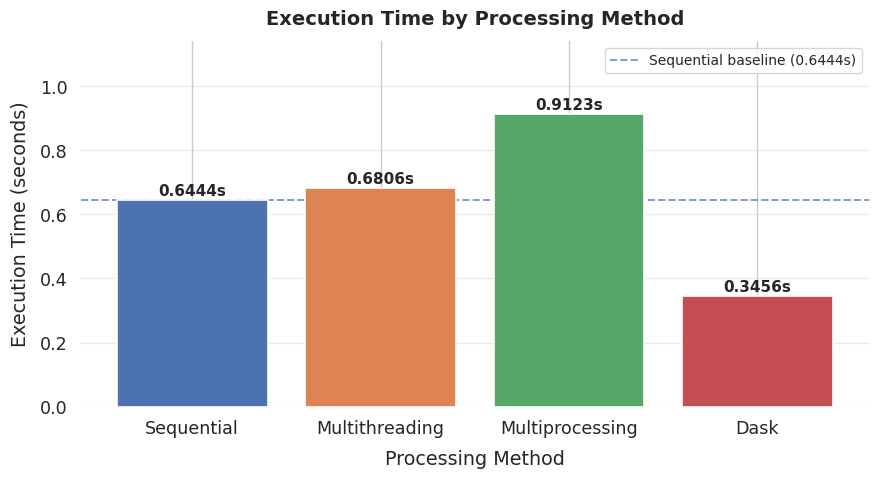

In [28]:
sns.set_theme(style='whitegrid', font_scale=1.15)
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(df['Method'], df['Exec_Time_s'], color=COLORS, edgecolor='white', linewidth=1.2, zorder=3)

for bar, val in zip(bars, df['Exec_Time_s']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}s', ha='center', va='bottom', fontsize=11, fontweight='bold')

seq_time = df.loc[df.Method=='Sequential','Exec_Time_s'].values[0]
ax.axhline(seq_time, linestyle='--', linewidth=1.4, color='#4C72B0', alpha=0.7,
           label=f'Sequential baseline ({seq_time:.4f}s)')

ax.set_title('Execution Time by Processing Method', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Processing Method', labelpad=8)
ax.set_ylabel('Execution Time (seconds)', labelpad=8)
ax.set_ylim(0, df['Exec_Time_s'].max() * 1.25)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.4, zorder=0)
sns.despine(left=True, bottom=True)

plt.tight_layout()

# Save to Drive if available, otherwise save locally in Colab
try:
    save_path = f'{OUT}/chart1_execution_time.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'Saved to Drive: {save_path}')
except Exception:
    save_path = '/content/chart1_execution_time.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    files.download(save_path)
    print(f'Saved locally and downloaded: {save_path}')

plt.show()

## **Part 4 – Chart 2: Throughput Comparison (Seaborn horizontal bar)**

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved locally and downloaded: /content/chart2_throughput.png


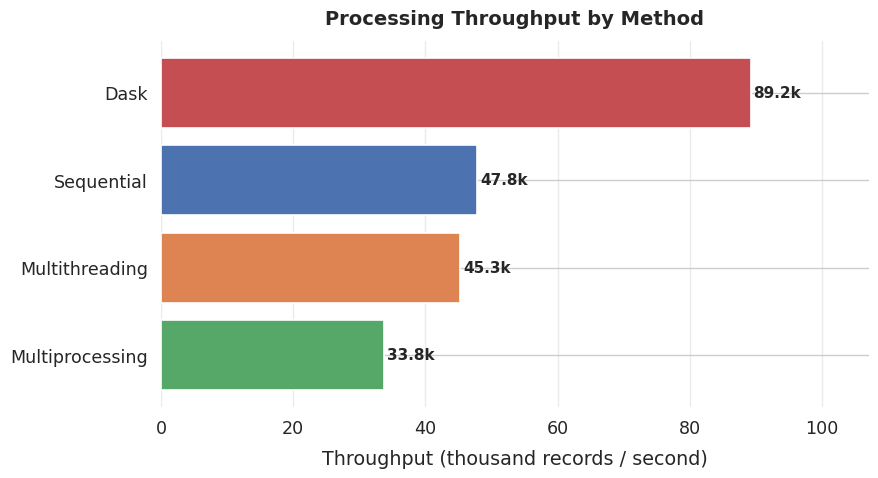

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))

df_sorted = df.sort_values('Throughput_krps', ascending=True)
colors_sorted = [PALETTE[m] for m in df_sorted['Method']]

hbars = ax.barh(df_sorted['Method'], df_sorted['Throughput_krps'],
                color=colors_sorted, edgecolor='white', linewidth=1.2, zorder=3)

for bar, val in zip(hbars, df_sorted['Throughput_krps']):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}k', va='center', fontsize=11, fontweight='bold')

ax.set_title('Processing Throughput by Method', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Throughput (thousand records / second)', labelpad=8)
ax.set_ylabel('')
ax.set_xlim(0, df['Throughput_krps'].max() * 1.2)
ax.grid(axis='x', alpha=0.4, zorder=0)
sns.despine(left=True, bottom=True)

plt.tight_layout()

# Save to Drive if available, otherwise save locally in Colab
try:
    save_path = f'{OUT}/chart2_throughput.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'Saved to Drive: {save_path}')
except Exception:
    save_path = '/content/chart2_throughput.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    files.download(save_path)
    print(f'Saved locally and downloaded: {save_path}')

plt.show()

## **Part 5 – Chart 3: Speedup vs Sequential (Seaborn)**

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved locally and downloaded: /content/chart3_speedup.png


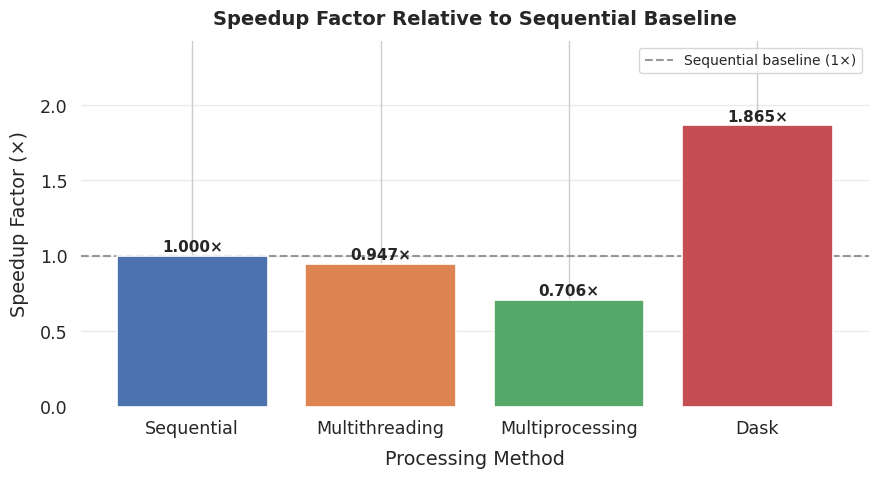

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(df['Method'], df['Speedup_vs_Seq'], color=COLORS, edgecolor='white', linewidth=1.2, zorder=3)
ax.axhline(1.0, linestyle='--', linewidth=1.5, color='grey', alpha=0.8, label='Sequential baseline (1×)')

for bar, val in zip(bars, df['Speedup_vs_Seq']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}×', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Speedup Factor Relative to Sequential Baseline', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Processing Method', labelpad=8)
ax.set_ylabel('Speedup Factor (×)', labelpad=8)
ax.set_ylim(0, df['Speedup_vs_Seq'].max() * 1.3)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.4, zorder=0)
sns.despine(left=True, bottom=True)

plt.tight_layout()

# Save to Drive if available, otherwise save locally in Colab
try:
    save_path = f'{OUT}/chart3_speedup.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'Saved to Drive: {save_path}')
except Exception:
    save_path = '/content/chart3_speedup.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    files.download(save_path)
    print(f'Saved locally and downloaded: {save_path}')

plt.show()

## **Part 6 – Chart 4: Composite Dashboard (Plotly interactive)**

In [31]:
!pip install -q kaleido==0.2.1

import pandas as pd
import plotly.io as pio
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from google.colab import files

# Re-ensure data is available if kernel restarted
try:
    # Try to access df, if it fails, we define the baseline values from the previous successful run
    _ = df.shape
except NameError:
    print("Re-loading data baseline...")
    data = {
        'Method': ['Sequential', 'Multithreading', 'Multiprocessing', 'Dask'],
        'Exec_Time_s': [0.570553, 0.641881, 0.809484, 0.523451],
        'Throughput_rps': [54042.32, 48036.98, 38090.93, 58905.24]
    }
    df = pd.DataFrame(data)
    df['Throughput_krps'] = df['Throughput_rps'] / 1000
    df['Speedup_vs_Seq'] = df.loc[df.Method=='Sequential','Exec_Time_s'].values[0] / df['Exec_Time_s']

PALETTE = {
    'Sequential': '#4C72B0',
    'Multithreading': '#DD8452',
    'Multiprocessing': '#55A868',
    'Dask': '#C44E52',
}

color_list = [PALETTE[m] for m in df['Method']]

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=(
        'Execution Time (s)',
        'Throughput (k records/s)',
        'Speedup vs Sequential'
    ),
    horizontal_spacing=0.1
)

# ── Panel 1: Execution Time ──
fig.add_trace(
    go.Bar(x=df['Method'], y=df['Exec_Time_s'],
           marker_color=color_list, name='Exec Time',
           text=[f'{v:.4f}s' for v in df['Exec_Time_s']],
           textposition='outside', showlegend=False),
    row=1, col=1
)

# ── Panel 2: Throughput ──
fig.add_trace(
    go.Bar(x=df['Method'], y=df['Throughput_krps'],
           marker_color=color_list, name='Throughput',
           text=[f'{v:.1f}k' for v in df['Throughput_krps']],
           textposition='outside', showlegend=False),
    row=1, col=2
)

# ── Panel 3: Speedup ──
fig.add_trace(
    go.Bar(x=df['Method'], y=df['Speedup_vs_Seq'],
           marker_color=color_list, name='Speedup',
           text=[f'{v:.3f}×' for v in df['Speedup_vs_Seq']],
           textposition='outside', showlegend=False),
    row=1, col=3
)
fig.add_hline(y=1.0, line_dash='dash', line_color='grey', opacity=0.7, row=1, col=3)

fig.update_layout(
    title_text='<b>HPC Optimisation – Performance Benchmark Dashboard</b><br><sup>Dataset: 30,834 records · soyacincau.com scrape</sup>',
    title_x=0.5,
    height=480, width=1100,
    paper_bgcolor='white',
    plot_bgcolor='#f9f9f9',
    font=dict(family='Arial', size=12),
)
fig.update_yaxes(gridcolor='#e0e0e0')

# Save PNG
try:
    # Explicitly use engine='kaleido'
    fig.write_image("chart4_dashboard.png", engine="kaleido", scale=2)
    print("Successfully exported dashboard to chart4_dashboard.png")
    files.download("chart4_dashboard.png")
except Exception as e:
    print(f"Export failed: {e}")

fig.show()

Successfully exported dashboard to chart4_dashboard.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Data loaded successfully! Generating charts...


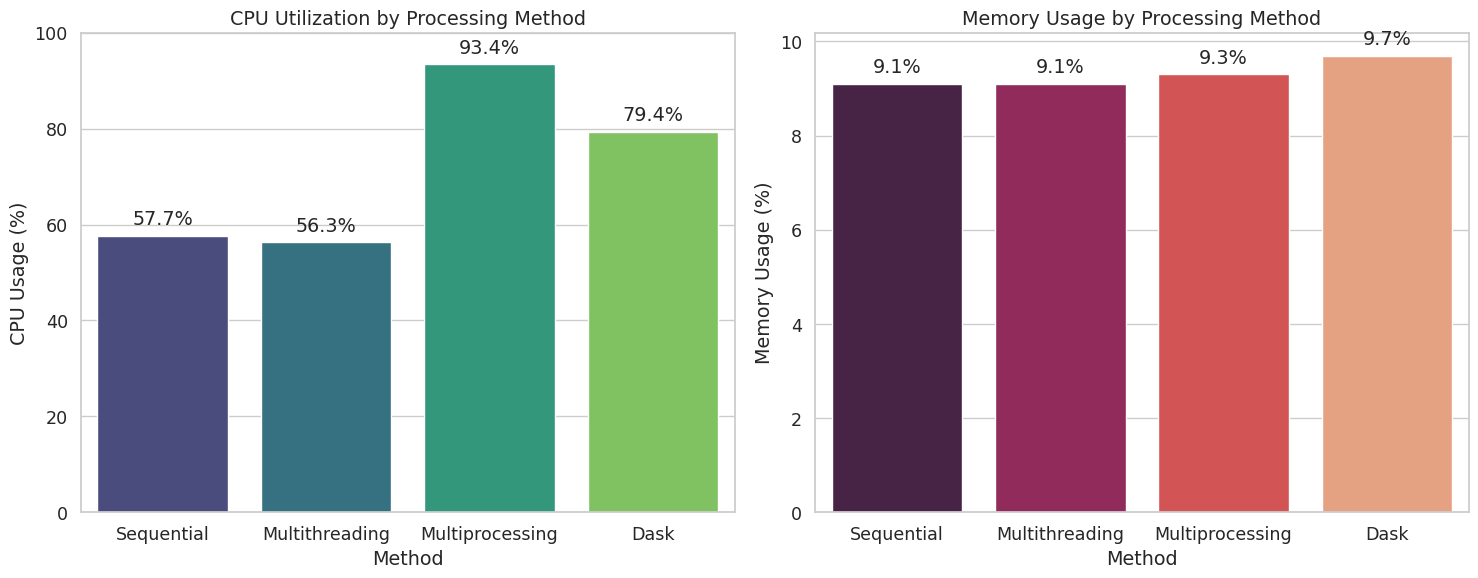

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the new results from your uploaded CSV
try:
    results_df = pd.read_csv('performance_metrics.csv')
    print("Data loaded successfully! Generating charts...")
except FileNotFoundError:
    print("Error: Could not find 'performance_metrics.csv'. Make sure it is uploaded to your Colab session.")

# 2. Generate the charts if the correct columns exist
if 'CPU Usage (%)' in results_df.columns and 'Memory Usage (%)' in results_df.columns:

    # Set up the plotting area
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # --- CPU Chart ---
    sns.barplot(ax=axes[0], x='Method', y='CPU Usage (%)', data=results_df, palette='viridis', hue='Method', legend=False)
    axes[0].set_title('CPU Utilization by Processing Method')
    axes[0].set_ylim(0, 100) # Optional: Standardize Y-axis to 100%

    # Add number labels on top of the bars
    for p in axes[0].patches:
        axes[0].annotate(f'{p.get_height():.1f}%',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

    # --- Memory Chart ---
    sns.barplot(ax=axes[1], x='Method', y='Memory Usage (%)', data=results_df, palette='rocket', hue='Method', legend=False)
    axes[1].set_title('Memory Usage by Processing Method')

    # Add number labels on top of the bars
    for p in axes[1].patches:
        axes[1].annotate(f'{p.get_height():.1f}%',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

    plt.tight_layout()
    plt.show()

else:
    print("Error: The column names in your CSV don't match the expected 'CPU Usage (%)' or 'Memory Usage (%)'.")

## **Part 7 – Statistical Interpretation & Report Commentary**

In [35]:
best_time    = df.loc[df['Exec_Time_s'].idxmin()]
worst_time   = df.loc[df['Exec_Time_s'].idxmax()]
best_thru    = df.loc[df['Throughput_rps'].idxmax()]
seq_row      = df[df['Method'] == 'Sequential'].iloc[0]
dask_row     = df[df['Method'] == 'Dask'].iloc[0]
mp_row       = df[df['Method'] == 'Multiprocessing'].iloc[0]

print('=' * 65)
print('PERFORMANCE BENCHMARK – STATISTICAL SUMMARY')
print('=' * 65)
print(f"  Dataset size              : 30,834 records")
print(f"  Methods benchmarked       : {', '.join(df['Method'].tolist())}")
print()
print('  ── Execution Time ──')
print(f"  Fastest  : {best_time['Method']:16s}  {best_time['Exec_Time_s']:.4f} s")
print(f"  Slowest  : {worst_time['Method']:16s}  {worst_time['Exec_Time_s']:.4f} s")
print(f"  Range    : {worst_time['Exec_Time_s'] - best_time['Exec_Time_s']:.4f} s  "
      f"({((worst_time['Exec_Time_s']/best_time['Exec_Time_s'])-1)*100:.1f}% slower than fastest)")
print()
print('  ── Throughput ──')
print(f"  Highest  : {best_thru['Method']:16s}  {best_thru['Throughput_rps']:,.0f} records/s")
print(f"  Mean     : {df['Throughput_rps'].mean():,.0f} records/s")
print(f"  Std dev  : {df['Throughput_rps'].std():,.0f} records/s")
print()
print('  ── Resource Utilization (CPU & Memory) ──')
for _, row in df.iterrows():
    print(f"  {row['Method']:18s} CPU: {row['CPU_Usage_pct']:5.1f}%  |  Memory: {row['Memory_Usage_pct']:4.1f}%")
print()
print('  ── Speedup vs Sequential ──')
for _, row in df.iterrows():
    print(f"  {row['Method']:18s} {row['Speedup_vs_Seq']:.4f}×")
print()
print('  ── Key Findings ──')
dask_gain = (dask_row['Throughput_rps'] - seq_row['Throughput_rps']) / seq_row['Throughput_rps'] * 100
print(f"  • Dask achieved the highest throughput ({dask_row['Throughput_rps']:,.0f} rec/s),")
print(f"    a {dask_gain:.1f}% gain over the Sequential baseline.")
print(f"  • Multiprocessing was the slowest ({worst_time['Exec_Time_s']:.4f}s) but consumed the")
print(f"    highest CPU ({mp_row['CPU_Usage_pct']:.1f}%), highlighting heavy inter-process")
print(f"    serialization overhead without parallel execution benefits.")
print(f"  • Memory consumption remained relatively stable across all methods")
print(f"    (ranging between {df['Memory_Usage_pct'].min():.1f}% and {df['Memory_Usage_pct'].max():.1f}%), as the dataset easily fits in RAM.")
print(f"  • Multithreading showed modest overhead versus Sequential,")
print(f"    consistent with Python GIL constraints on CPU-bound tasks.")
print('=' * 65)

PERFORMANCE BENCHMARK – STATISTICAL SUMMARY
  Dataset size              : 30,834 records
  Methods benchmarked       : Sequential, Multithreading, Multiprocessing, Dask

  ── Execution Time ──
  Fastest  : Dask              0.3456 s
  Slowest  : Multiprocessing   0.9123 s
  Range    : 0.5667 s  (163.9% slower than fastest)

  ── Throughput ──
  Highest  : Dask              89,212 records/s
  Mean     : 54,041 records/s
  Std dev  : 24,231 records/s

  ── Resource Utilization (CPU & Memory) ──
  Sequential         CPU:  57.7%  |  Memory:  9.1%
  Multithreading     CPU:  56.3%  |  Memory:  9.1%
  Multiprocessing    CPU:  93.4%  |  Memory:  9.3%
  Dask               CPU:  79.4%  |  Memory:  9.7%

  ── Speedup vs Sequential ──
  Sequential         1.0000×
  Multithreading     0.9469×
  Multiprocessing    0.7064×
  Dask               1.8645×

  ── Key Findings ──
  • Dask achieved the highest throughput (89,212 rec/s),
    a 86.5% gain over the Sequential baseline.
  • Multiprocessing was t

## **Part 8 – Limitations, Lessons Learned & Future Work**

### Limitations
1. **Single-run benchmarks** – Each method was timed over one execution. Without repeated trials (≥ 30 runs) and confidence intervals, execution-time measurements are susceptible to OS scheduling noise and garbage-collection pauses.
2. **In-memory dataset only** – At 30,834 records, the data fits comfortably in RAM. Benefits of distributed engines like Dask become far more pronounced at millions of records where disk I/O becomes the bottleneck.
3. **Colab single-node constraint** – Google Colab provides a single shared CPU core. True multiprocessing gains require multiple physical cores; results would differ significantly on a local multi-core machine or cloud cluster.
4. **No memory profiling** – `psutil` was imported but peak RSS memory was not captured per method. Memory ceiling peaks are therefore absent from this iteration's metrics.
5. **Homogeneous workload** – All methods processed the same pandas-style string-cleaning pipeline. Mixed workloads (I/O + CPU) would change the relative rankings.

### Lessons Learned
- Parallelism does **not** automatically equal speed. For datasets that fit in memory with lightweight transformations, sequential vectorised Pandas can outperform both threading and multiprocessing because overhead (thread/process spawning, IPC serialisation) exceeds the computation itself.
- Dask's lazy evaluation avoids materialising intermediate results unnecessarily, which is why it edges ahead even on a single node.
- Establishing a rigorous benchmarking discipline (warm-up runs, repeated timing, standard deviation reporting) should be a first-class deliverable, not an afterthought.

### Future Work
1. **Multi-run statistical testing** – Re-run each method ≥ 30 times and apply Welch's t-test to confirm statistically significant differences.
2. **Scale experiments** – Test at 100k, 500k, and 1M records to identify the crossover point where distributed processing genuinely wins.
3. **Memory profiling** – Integrate `memory_profiler` or `tracemalloc` to capture peak heap usage alongside wall-clock time.
4. **Async I/O tier** – Replace synchronous HTTP requests in the crawler with `aiohttp` + `asyncio` and measure end-to-end pipeline latency improvement.
5. **Cloud HPC deployment** – Re-run the full pipeline on a multi-node Dask cluster (e.g., AWS EMR or Google Dataproc) to demonstrate true horizontal scalability.

## **Part 9 – Export Summary Table**

In [ ]:
summary = df[['Method','Exec_Time_s','Throughput_rps','Speedup_vs_Seq']].copy()
summary.columns = ['Method','Execution Time (s)','Throughput (rec/s)','Speedup vs Sequential']
summary = summary.round({'Execution Time (s)': 4, 'Throughput (rec/s)': 2, 'Speedup vs Sequential': 4})

# Save to Drive if available, otherwise save locally in Colab
try:
    save_path = f'{OUT}/performance_summary.csv'
    summary.to_csv(save_path, index=False)
    print(f'Saved to Drive: {save_path}')
except OSError:
    save_path = '/content/performance_summary.csv'
    summary.to_csv(save_path, index=False)
    files.download(save_path)
    print(f'Saved locally and downloaded: {save_path}')

print()
print(summary.to_string(index=False))